In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [40]:
#1) Handling missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [41]:
df.drop('deck',axis=1,inplace=True,errors='ignore')
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town']=df['embark_town'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [42]:
# 2) Remove missing values.
df.duplicated().sum()

np.int64(116)

In [43]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [44]:
# 3)Outlier Detection & Capping
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=[col for col in num_cols if df[col].nunique() > 10]
print('NUMERICAL COLUMNS :',num_cols)
print('CONTINIOUS COLMNS :',cat_cols)

NUMERICAL COLUMNS : Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
CONTINIOUS COLMNS : ['age', 'fare']


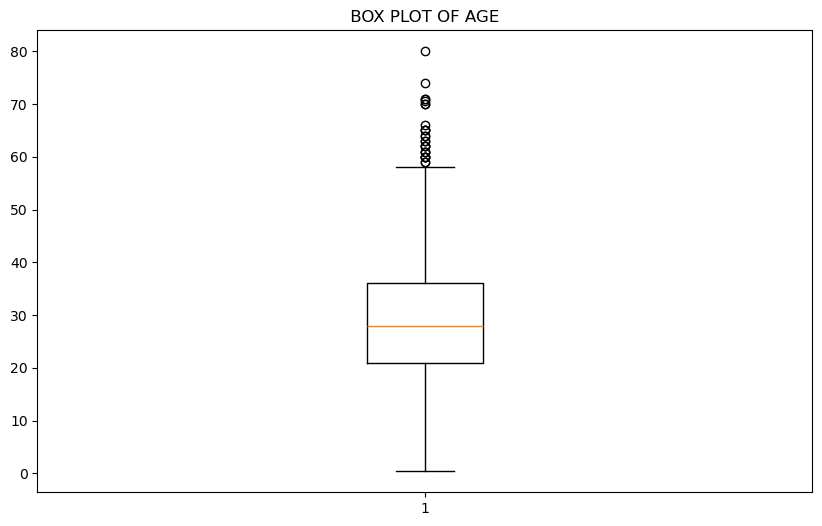

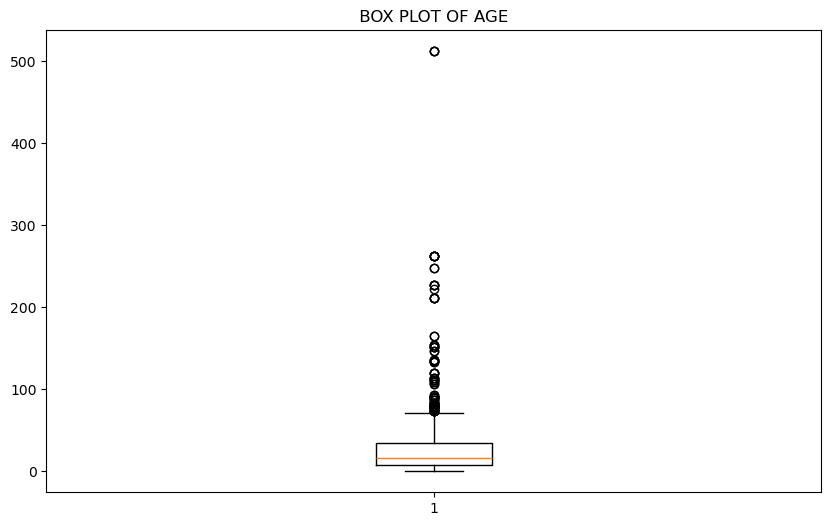

C:\Users\AKARSH.K\AppData\Local\Temp\ipykernel_26596\3628294285.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in continous_cols],labels=continous_cols )


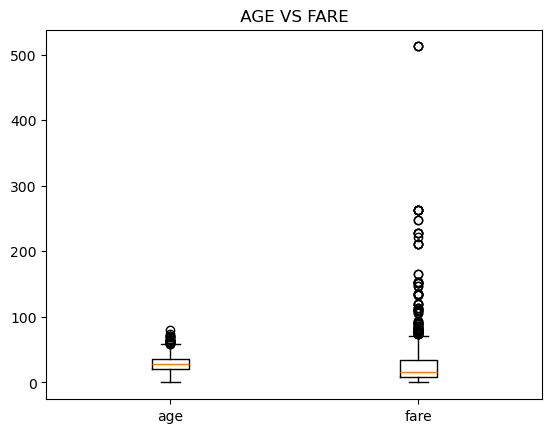

In [45]:
plt.figure(figsize=(10,6))
plt.boxplot(df['age'])
plt.title(' BOX PLOT OF AGE ')
plt.show()


plt.figure(figsize=(10,6))
plt.boxplot(df['fare'])
plt.title(' BOX PLOT OF AGE ')
plt.show()

continous_cols=['age','fare']
plt.boxplot([df[col] for col in continous_cols],labels=continous_cols )
plt.title(' AGE VS FARE ')
plt.show()

C:\Users\AKARSH.K\AppData\Local\Temp\ipykernel_26596\3803696005.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in continous_cols], labels=continous_cols)


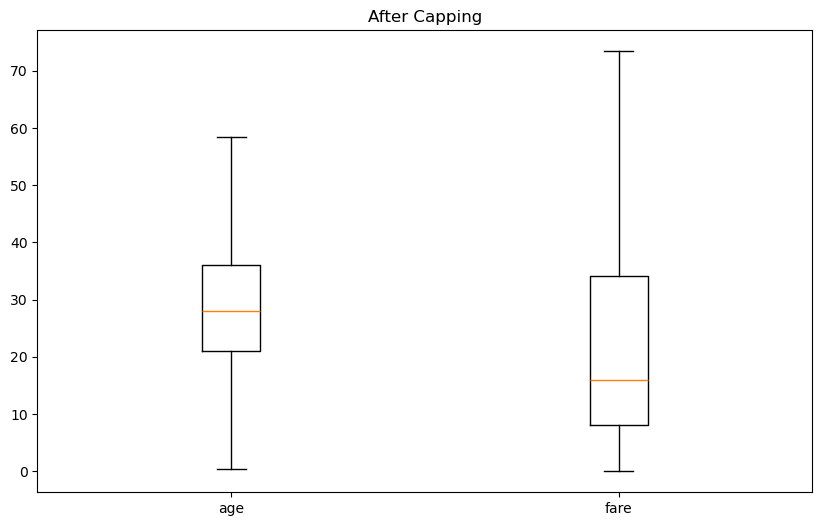

 Outlier Detection and Capping done


In [46]:
def outlier_capping(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[column] = data[column].apply(lambda x: lower if x < lower else upper if x > upper else x)
for col in continous_cols:
    outlier_capping(df, col)
plt.figure(figsize=(10,6))
plt.boxplot([df[col] for col in continous_cols], labels=continous_cols)
plt.title('After Capping')
plt.show()
print(" Outlier Detection and Capping done")